In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from setfit import SetFitModel, Trainer, TrainingArguments 

from sklearn.metrics import(
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    multilabel_confusion_matrix
)

c:\Users\rebec\miniconda3\envs\setfit-thesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#predetermined seed for later randomisation
SEED = 42 

#define text column
text_col = "Text"

#define label column
label_columns = [
    "Meaninglessness",
    "Loneliness",
    "Death Anxiety",
    "Death Acceptance",
    "Identity Confusion",
    "Freedom Responsibility",
    "Engagement",
    "Solitude"
]

In [3]:
dev_df = pd.read_csv("Development_set.csv", encoding="utf-8-sig")
print(dev_df.head())
print(dev_df.shape)

test_df = pd.read_csv("Test_set.csv", encoding="utf-8-sig")
print(test_df.head())
print(test_df.shape)


     Post_id                                               Text  \
0  POST_0046  Life is like a TV series that keeps getting re...   
1  POST_1526  The New Agora: Daily WWYD and light discussion...   
2  POST_0953  When exactly does free will happen? [SEP] To b...   
3  POST_0047  Archetypes (Jung, Hillman) vs existentialism a...   
4  POST_1357  How do you let go of someone you love? [SEP] I...   

   Death Anxiety  Death Acceptance  Loneliness  Solitude  Identity Confusion  \
0              0                 0           0         0                   0   
1              0                 0           0         0                   0   
2              0                 0           0         0                   0   
3              0                 0           0         0                   0   
4              0                 0           0         0                   0   

   Freedom Responsibility  Meaninglessness  Engagement  
0                       0                1           0  
1 

In [4]:
#check the column names to avoid spelling mistakes / whitespaces
print("Development set columns: ")
print(dev_df.columns.tolist())

print("Test set columns: ")
print(test_df.columns.tolist())

Development set columns: 
['Post_id', 'Text', 'Death Anxiety', 'Death Acceptance', 'Loneliness', 'Solitude', 'Identity Confusion', 'Freedom Responsibility', 'Meaninglessness', 'Engagement']
Test set columns: 
['Post_id', 'Text', 'Death Anxiety', 'Death Acceptance', 'Loneliness', 'Solitude', 'Identity Confusion', 'Freedom Responsibility', 'Meaninglessness', 'Engagement']


In [5]:
# Rather code it so that it checks for whether all posts are either coded 0 or 1 and otherwise giving an error with the respective post_ID
def clean_label_value(value):
    if pd.isna(value):
        return 0
    
    if isinstance(value, str):
        value = value.strip()

        if value.endswith("?"):
            value = value[:-1].strip()

        if value in {"0", "0.0"}:
            return 0
        
        if value in {"1", "1.0"}:
            return 1
        
    try:
        return int(float(value))
    
    except Exception as err:
        raise ValueError(f"Unexpected label value: {value!r}") from err

In [6]:
# Clean datasets
datasets = {
    "development": dev_df,
    "test": test_df,
}

for name, df in datasets.items():
    for col in label_columns:
        df[col] = df[col].apply(clean_label_value)

    df["labels"] = df[label_columns].astype(int).values.tolist()

    print(f"\n{name} set:")
    print(df[[text_col, "labels"]].head())


development set:
                                                Text                    labels
0  Life is like a TV series that keeps getting re...  [1, 0, 0, 0, 0, 0, 0, 0]
1  The New Agora: Daily WWYD and light discussion...  [0, 0, 0, 0, 0, 0, 0, 0]
2  When exactly does free will happen? [SEP] To b...  [0, 0, 0, 0, 0, 0, 0, 0]
3  Archetypes (Jung, Hillman) vs existentialism a...  [0, 0, 0, 0, 0, 0, 0, 0]
4  How do you let go of someone you love? [SEP] I...  [0, 0, 0, 0, 0, 0, 0, 0]

test set:
                                                Text                    labels
0  I really hate when people invalidate a depress...  [0, 0, 0, 0, 0, 0, 0, 0]
1  A Stoic Parable to Memorize [SEP] I'm a dad wh...  [0, 0, 0, 0, 0, 1, 0, 0]
2  it will be no longer very soon [SEP] it, being...  [1, 0, 0, 0, 0, 0, 0, 0]
3  Does anyone else feel too weird for normal peo...  [0, 1, 0, 0, 0, 0, 0, 0]
4  Life has no meaning [SEP] There's no reason wh...  [1, 0, 0, 0, 0, 0, 0, 0]


In [7]:
# Check number of occurrences per label
for name, df in datasets.items():
    print(f"\n{name} set: ")

    # Count appearances of each label
    label_counts = df[label_columns].sum()
    print("Label counts: ", label_counts)

    # Count posts with at least one label
    labeled_posts = (df[label_columns].sum(axis=1) > 0).sum()
    print("Posts that contain at least one label: ", labeled_posts)

    # Count posts with no label
    posts_without_label = len(df) - labeled_posts
    print("Posts without any label: ", posts_without_label)

    # Count all positive labels
    labeled_total = df[label_columns].sum().sum()
    print("Total number of positive labels: ", labeled_total)


development set: 
Label counts:  Meaninglessness           34
Loneliness                23
Death Anxiety             22
Death Acceptance          11
Identity Confusion        12
Freedom Responsibility     7
Engagement                 7
Solitude                  12
dtype: int64
Posts that contain at least one label:  111
Posts without any label:  339
Total number of positive labels:  128

test set: 
Label counts:  Meaninglessness           4
Loneliness                3
Death Anxiety             2
Death Acceptance          1
Identity Confusion        1
Freedom Responsibility    1
Engagement                1
Solitude                  1
dtype: int64
Posts that contain at least one label:  14
Posts without any label:  36
Total number of positive labels:  14


In [ ]:
def evaluate_setfit_model(model, dataset, dataset_name):
    texts = dataset[text_col]
    # Codes as provided by human coding
    y_true = np.array(dataset["labels"])

    # model's final binary decision per label
    y_pred = model.predict(texts)
  

    if torch.is_tensor(y_pred):
        y_pred = y_pred.detach().cpu().numpy()

    else:
        y_pred = np.asarray(y_pred)
        

    # Prediction scores per label
    y_proba = model.predict_proba(texts)

    if torch.is_tensor(y_proba):
        y_proba = y_proba.detach().cpu().numpy()

    else:
        y_proba = np.asarray(y_proba)

    results = {
        "dataset": dataset_name,
        "macro_f1": f1_score(y_true, y_pred, average = "macro", zero_division = 0),
        "micro_f1": f1_score(y_true, y_pred, average = "micro", zero_division = 0),
        "macro_precision": precision_score(y_true, y_pred, average = "macro", zero_division = 0),
        "micro_precision": precision_score(y_true, y_pred, average = "micro", zero_division = 0),
        "macro_recall": recall_score(y_true, y_pred, average = "macro", zero_division = 0),
        "micro_recall": recall_score(y_true, y_pred, average = "micro", zero_division = 0)
    }

    return results, y_true, y_pred, y_proba

In [ ]:
# Creating the 3 folds for cross validation
X_dev = dev_df["Text"]

y_dev = dev_df[label_columns].to_numpy()

mskf = MultilabelStratifiedKFold(
    n_splits=3, 
    shuffle=True, 
    random_state=42
)

# Creating a list to collect the validation metrics
val_metrics = []

# Creating a list to collect the  metrics per label
label_metrics = []

# Creating a list to collect the prediction metrics
predictions = []

# For-loop for multilabel 3-fold cross-validation
for i, (train_index, validation_index) in enumerate(mskf.split(X_dev, y_dev)):

    fold_number = i + 1

    print("Fold ", fold_number)
    print("Training posts: ", len(train_index))
    print("Validation posts: ", len(validation_index))

    validation_labels = y_dev[validation_index]
    validation_counts = validation_labels.sum(axis=0)


    for j in range(len(label_columns)):
        print(label_columns[j], ": ", validation_counts[j])

    fold_train_df = dev_df.iloc[train_index].copy()
    fold_val_df = dev_df.iloc[validation_index].copy()

    fold_train_df.to_csv(f"Train_fold_{fold_number}.csv", index = False)
    fold_val_df.to_csv(f"Validation_fold_{fold_number}.csv", index = False)

   
    train_fold_dataset = Dataset.from_pandas(
    fold_train_df[[text_col, "labels"]].reset_index(drop = True)
    )

    validation_fold_dataset = Dataset.from_pandas(
    fold_val_df[[text_col, "labels"]].reset_index(drop = True)
    )

    # Define the settings for the model training
    args = TrainingArguments(
        output_dir = f"setfit_output/fold_{fold_number}",
        batch_size = (16, 2),
        num_epochs = (1, 16),
        #num_iterations = 2,
        sampling_strategy = "oversampling", #CHECK
        seed = SEED,
        show_progress_bar = True, 
    )

    num_classes = len(label_columns)

    # Initialise the SetFit Model and the selected Sentence Transformer model, e.g., "BAAI/bge-small-en-v1.5", "all-MiniLM-L6-v2" (run before), "jinaai/jina-embeddings-v5-text-nano"(favourite)
    model = SetFitModel.from_pretrained(
        "BAAI/bge-small-en-v1.5",
        multi_target_strategy="one-vs-rest", # multilabel differerntiable head with one binary output per label
        use_differentiable_head=True,
        head_params={"out_features": num_classes},
    )
    print("Model loaded. Train it before using for inference.")


    # Initialise the Trainer
    trainer = Trainer(
        model=model,
        args = args,
        train_dataset = train_fold_dataset,
        eval_dataset = validation_fold_dataset,
        column_mapping={
            "Text": "text",
            "labels": "label"
        }
    )

    # Starting the training of SetFit
    trainer.train()

    # Evaluation of the trained model - overall accuracy and overall f1-scores
    metrics = trainer.evaluate()
    print(metrics)

    # Initialising the evaluation of the validation dataset
    validation_results, y_true_val, y_pred_val, y_proba_val = evaluate_setfit_model(
        model,
        validation_fold_dataset,
        "validation"
    )

    print(validation_results)
    
    print("True positive labels:", y_true_val.sum())
    print("Predicted positive labels:", y_pred_val.sum())

    # Appending fold results to a list
    fold_results = validation_results.copy()
    fold_results["fold"] = fold_number

    val_metrics.append(fold_results)

    # Storing post-level validation predictions and probabilities in a list
    for idx in range(len(fold_val_df)):
        val_post = fold_val_df.iloc[idx]

        fold_post_metrics ={
            "fold": fold_number,
            "post_id": val_post["Post_id"]
        }

        for j, label in enumerate(label_columns):
            fold_post_metrics[f"true_{label}"] = y_true_val[idx][j]
            fold_post_metrics[f"pred_{label}"] = y_pred_val[idx][j]
            fold_post_metrics[f"prob_{label}"] = y_proba_val[idx][j] #CHECK if they are truly saved


        predictions.append(fold_post_metrics)

    # Labelwise classificaion report

    label_report = classification_report(
        y_true_val,
        y_pred_val,
        target_names= label_columns,
        zero_division= 0,
        output_dict= True    
    )
    
    print(label_report)

    # Storing per-label metrics for the current fold in a list
    for l in label_columns:
        label_retrieval = label_report.get(l)

        fold_label_entry ={
            "fold": fold_number,
            "label": l,
            "precision": label_retrieval["precision"],#
            "recall": label_retrieval["recall"],
            "f1_score": label_retrieval["f1-score"],
            "support": label_retrieval["support"]
        }

        label_metrics.append(fold_label_entry)



# Convert lists into pd dataframes for csv file storage
val_metrics_df = pd.DataFrame(val_metrics)
label_metrics_df = pd.DataFrame(label_metrics)
predictions_df = pd.DataFrame(predictions)

# Store metrics dataframes as csv files 
val_metrics_df.to_csv("Validation_fold_metrics.csv", index = False) 
label_metrics_df.to_csv("Per_label_fold_metrics.csv", index = False)
predictions_df.to_csv("Prediction_metrics.csv", index = False)                   


Fold  1
Training posts:  300
Validation posts:  150
Meaninglessness :  11
Loneliness :  8
Death Anxiety :  7
Death Acceptance :  3
Identity Confusion :  4
Freedom Responsibility :  2
Engagement :  3
Solitude :  4


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
C:\Users\rebec\setfit\src\setfit\modeling.py:849: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  "in_features": model_body.get_sentence_embedding_dimension(),
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset


Model loaded. Train it before using for inference.


Map: 100%|██████████| 300/300 [00:00<00:00, 11015.61 examples/s]
***** Running training *****
  Num unique pairs = 1262
  Batch size = 16
  Num epochs = 1
c:\Users\rebec\miniconda3\envs\setfit-thesis\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
1,0.229600
50,0.173900


The `max_length` is `None`. Using the maximum acceptable length according to the current model body: 512.
Epoch:   0%|          | 0/16 [00:00<?, ?it/s]c:\Users\rebec\miniconda3\envs\setfit-thesis\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch:  19%|█▉        | 3/16 [15:56<1:09:04, 318.78s/it]


KeyboardInterrupt: 

In [ ]:
# Evaluation of the model based on mean macro-F1 (primary evaluation criterion) and mean micro-F1 (secondary evaluation criterion)
cv_evaluation ={
    "mean_macro_f1" : val_metrics_df["macro_f1"].mean(),
    "sd_macro_f1" : val_metrics_df["macro_f1"].std(),
    "mean_micro_f1" : val_metrics_df["micro_f1"].mean(),
    "sd_micro_f1" : val_metrics_df["micro_f1"].std()
}

cv_evaluation

cv_evaluation_df = pd.DataFrame([cv_evaluation])
cv_evaluation_df.to_csv("Cross_validation_evaluation.csv", index = False)

In [ ]:
#STOP between model development and evaluation with test set

In [28]:
# Define the settings for the model training
args = TrainingArguments(
    output_dir = "setfit_output",
    batch_size = 16,
    num_epochs = 2,
    num_iterations = 2,
    sampling_strategy = "oversampling",
    seed = SEED,
    show_progress_bar = True, 
)

In [29]:
num_classes = len(label_columns)

# Initialise the SetFit Model and the selected Sentence Transformer model, e.g., "BAAI/bge-small-en-v1.5", "all-MiniLM-L6-v2" (run before), "jinaai/jina-embeddings-v5-text-nano"(favourite)
model = SetFitModel.from_pretrained(
    "BAAI/bge-small-en-v1.5",
    multi_target_strategy="one-vs-rest",
    use_differentiable_head=True,
    head_params={"out_features": num_classes},
)
print("Model loaded. Train it before using for inference.")

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Model loaded. Train it before using for inference.


C:\Users\rebec\setfit\src\setfit\modeling.py:849: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  "in_features": model_body.get_sentence_embedding_dimension(),


In [ ]:
# Initialise the Trainer
trainer = Trainer(
    model=model,
    args = args,
    train_dataset = train_fold_dataset,
    eval_dataset = validation_dataset,
    column_mapping={
        "Text": "text",
        "labels": "label"
    }
)

# Starting the training of SetFit
trainer.train()

Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Map: 100%|██████████| 400/400 [00:00<00:00, 15820.40 examples/s]
***** Running training *****
  Num unique pairs = 1600
  Batch size = 16
  Num epochs = 2
c:\Users\rebec\miniconda3\envs\setfit-thesis\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
1,0.137300
50,0.184600
100,0.105900
150,0.064400
200,0.057700


The `max_length` is `None`. Using the maximum acceptable length according to the current model body: 512.
Epoch:   0%|          | 0/2 [00:00<?, ?it/s]c:\Users\rebec\miniconda3\envs\setfit-thesis\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch: 100%|██████████| 2/2 [08:42<00:00, 261.34s/it]


In [31]:
# Evaluation of the trained model - accuracy and f1-scores
metrics = trainer.evaluate(validation_dataset)
print(metrics)

def evaluate_setfit_model(model, dataset, dataset_name):
    texts = dataset[text_col]
    y_true = np.array(dataset["labels"])

    y_pred = model.predict(texts)
    y_pred = np.array(y_pred)

    results = {
        "dataset": dataset_name,
        "macro_f1": f1_score(y_true, y_pred, average = "macro", zero_division = 0),
        "micro_f1": f1_score(y_true, y_pred, average = "micro", zero_division = 0),
        "macro_precision": precision_score(y_true, y_pred, average = "macro", zero_division = 0),
        "micro_precision": precision_score(y_true, y_pred, average = "micro", zero_division = 0),
        "macro_recall": recall_score(y_true, y_pred, average = "macro", zero_division = 0),
        "micro_recall": recall_score(y_true, y_pred, average = "micro", zero_division = 0)
    }

    return results, y_true, y_pred

# Initialising the evaluation of the validation dataset
validation_results, y_true_val, y_pred_val = evaluate_setfit_model(
    model,
    validation_dataset,
    "validation"
)

print(validation_results)

Applying column mapping to the evaluation dataset
***** Running evaluation *****


{'accuracy': 0.66}
{'dataset': 'validation', 'macro_f1': 0.0, 'micro_f1': 0.0, 'macro_precision': 0.0, 'micro_precision': 0.0, 'macro_recall': 0.0, 'micro_recall': 0.0}


C:\Users\rebec\AppData\Local\Temp\ipykernel_27188\3868458698.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_pred = np.array(y_pred)


In [32]:
print("True positive labels:", y_true_val.sum())
print("Predicted positive labels:", y_pred_val.sum())

True positive labels: 20
Predicted positive labels: 0


In [33]:
# Labelwise classificaion report
print(classification_report(
    y_true_val,
    y_pred_val,
    target_names = label_columns, 
    zero_division = 0
))

                        precision    recall  f1-score   support

       Meaninglessness       0.00      0.00      0.00         4
            Loneliness       0.00      0.00      0.00         4
         Death Anxiety       0.00      0.00      0.00         2
      Death Acceptance       0.00      0.00      0.00         1
    Identity Confusion       0.00      0.00      0.00         3
    Identity Synthesis       0.00      0.00      0.00         0
Freedom Responsibility       0.00      0.00      0.00         2
     Freedom Paralysis       0.00      0.00      0.00         0
            Engagement       0.00      0.00      0.00         2
              Solitude       0.00      0.00      0.00         2

             micro avg       0.00      0.00      0.00        20
             macro avg       0.00      0.00      0.00        20
          weighted avg       0.00      0.00      0.00        20
           samples avg       0.00      0.00      0.00        20



In [34]:
# Multilabel confusion matrix
conf_matrix = multilabel_confusion_matrix(y_true_val, y_pred_val)

for label, matrix in zip(label_columns, conf_matrix):
    print(f"\n{label}")
    print(matrix)


Meaninglessness
[[46  0]
 [ 4  0]]

Loneliness
[[46  0]
 [ 4  0]]

Death Anxiety
[[48  0]
 [ 2  0]]

Death Acceptance
[[49  0]
 [ 1  0]]

Identity Confusion
[[47  0]
 [ 3  0]]

Identity Synthesis
[[50  0]
 [ 0  0]]

Freedom Responsibility
[[48  0]
 [ 2  0]]

Freedom Paralysis
[[50  0]
 [ 0  0]]

Engagement
[[48  0]
 [ 2  0]]

Solitude
[[48  0]
 [ 2  0]]


                    Label  TN  FP  FN  TP
0         Meaninglessness  46   0   4   0
1              Loneliness  46   0   4   0
2           Death Anxiety  48   0   2   0
3        Death Acceptance  49   0   1   0
4      Identity Confusion  47   0   3   0
5      Identity Synthesis  50   0   0   0
6  Freedom Responsibility  48   0   2   0
7       Freedom Paralysis  50   0   0   0
8              Engagement  48   0   2   0
9                Solitude  48   0   2   0


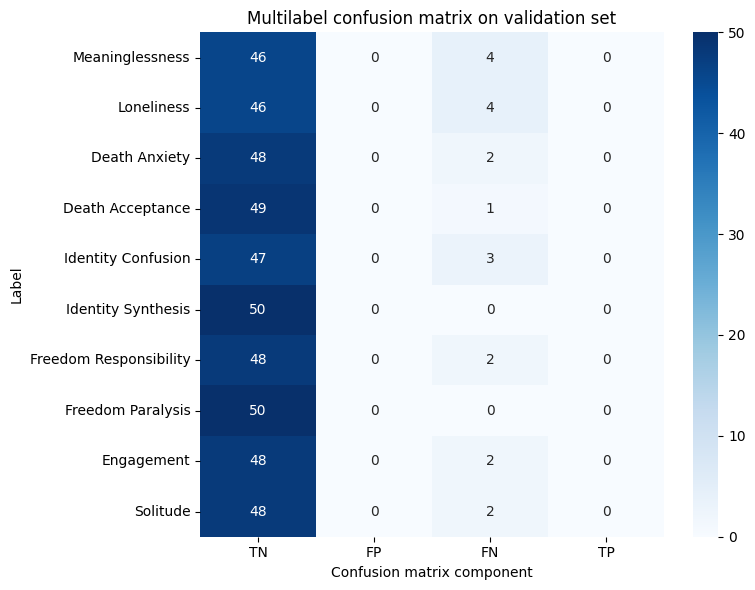

In [35]:
# Preprocessing for the visualisation of the multilabel confusion matrix

confusion_rows = []

for label, matrix in zip(label_columns, conf_matrix):
    tn, fp, fn, tp = matrix.ravel()

    confusion_rows.append({
        "Label": label,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

confusion_df = pd.DataFrame(confusion_rows)

print(confusion_df)

# Visualisation as a heatmap of the multilabel confusion matrix
plt.figure(figsize = (8, 6))

sns.heatmap(
    confusion_df.set_index("Label"),
    annot = True,
    fmt = "d",
    cmap = "Blues"
)

plt.title("Multilabel confusion matrix on validation set")
plt.xlabel("Confusion matrix component"),
plt.ylabel("Label")
plt.tight_layout()
plt.show()